In [1]:
import flax.linen as nn
import jax
import optax
from flax.training.train_state import TrainState
import numpy as np

import cobra
from cobra.io import load_model
import pandas as pd
from cobra.util import array


In [2]:
# This is an E.Coli model that comes bundled with cobrapy
model = load_model("iJO1366")
# Do this just once at the beginning
model, removed_rxns = cobra.manipulation.prune_unused_reactions(model)
S = array.create_stoichiometric_matrix(model, array_type='dense')

In [5]:
NUM_KNOCKOUT_GENES=1
if NUM_KNOCKOUT_GENES == 1:
    means = pd.read_csv('flux_train_set_stats/ecoli_reaction_means_50k.csv') #, index_col=0).squeeze("columns")
    stds = pd.read_csv('flux_train_set_stats/ecoli_reaction_stds_50k.csv')
else:
    means = pd.read_csv('flux_train_set_stats/ecoli_reaction_means_double_dropout_50k.csv') #, index_col=0).squeeze("columns")
    stds = pd.read_csv('flux_train_set_stats/ecoli_reaction_stds_double_dropout_50k.csv')
means = np.array(means['fluxes'])
stds = np.array(stds['fluxes'])

active_rxns_mask = stds > 1e-6
filtered_stds = stds[active_rxns_mask]
filtered_means = means[active_rxns_mask]

print(stds.shape, means.shape)

(2583,) (2583,)


In [4]:
#means = np.zeros_like(model.reactions)
#sq_difs_from_mean = np.zeros_like(model.reactions)
#stds = np.zeros_like(model.reactions)

(dtype('float64'), dtype('float64'))

In [ ]:

# This only needs to be run once. The resulting mean and std devs per reaction were saved to CSV
# and we just reload from there. 

count = 0
all_gene_masks = []
all_unnorm_fluxes = []
means = np.zeros_like(model.reactions)
sq_difs_from_mean = np.zeros_like(model.reactions)
stds = np.zeros_like(model.reactions)
# Welford's algorithm for maintaining an online mean and std
for i in range(50000):
    num_genes = np.random.randint(low=NUM_KNOCKOUT_GENES, high=NUM_KNOCKOUT_GENES+1)
    #print(num_genes)
    # First 50 genes are reserved for test set. We will still get fluxes for all reactions.
    gene_idxs = np.random.randint(low=50, high=len(model.genes), size=(num_genes,))
    gene_mask = np.zeros((len(model.genes),), dtype=np.uint8)
    gene_mask[gene_idxs] = 1
    all_gene_masks.append(gene_mask)
    #print(gene_idxs, type(gene_idxs), gene_idxs.dtype)
    drop_genes = list(np.take(model.genes, gene_idxs))
    #print(drop_genes)
    with model:
        # Using delete_model_genes will modify the reaction network, which we cannot have
        # because we need the reactions/fluxes to stay fixed. We assume a static graph.
        cobra.manipulation.knock_out_model_genes(model, drop_genes)
        # Check validity
        solution = model.optimize()
        if solution.status == 'optimal':
            count += 1
            all_unnorm_fluxes.append(np.array(solution.fluxes))
            delta = solution.fluxes - means
            means = means + delta/count
            sq_difs_from_mean = sq_difs_from_mean + delta*(solution.fluxes - means)
    if i % 1000 == 0:
        print(i)

variances = sq_difs_from_mean / (count - 1)
stds = np.pow(variances, 0.5)

means.to_csv('flux_train_set_stats/ecoli_reaction_means_50k.csv', index=False, header=True)
stds.to_csv('flux_train_set_stats/ecoli_reaction_stds_50k.csv', index=False, header=True)
# We only need to do this once.

In [12]:
means = means.to_numpy(dtype=np.float32)
stds = stds.to_numpy(dtype=np.float32)

active_rxns_mask = stds > 1e-6
filtered_stds = stds[active_rxns_mask]
filtered_means = means[active_rxns_mask]

In [16]:
# Run Ridge regression as a baseline. This will tell us if the problem is non-linear (MLP would outperform Ridge).
# This requires creating the entire dataset up front, so can run this if running the previous cell.
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

ridge = Ridge(alpha=1.0, fit_intercept=True)
gene_masks = np.array(all_gene_masks)
unnorm_fluxes = np.array(all_unnorm_fluxes)[:, active_rxns_mask]
active_means = means[active_rxns_mask]
active_stds = stds[active_rxns_mask]

norm_fluxes = (unnorm_fluxes - active_means) / active_stds
norm_fluxes.shape
ridge.fit(gene_masks, norm_fluxes)
#unnorm_fluxes.shape, gene_masks.shape


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [19]:
def get_next_sample(model, is_train=True, max_gene_knockouts=3):
    found = False
    low_idx = 50 if is_train else 0
    high_idx = 50 if not is_train else len(model.genes)
    while not found:
        num_genes = np.random.randint(low=NUM_KNOCKOUT_GENES, high=NUM_KNOCKOUT_GENES+1)
        #print(num_genes)
        gene_idxs = np.random.randint(low=low_idx, high=high_idx, size=(num_genes,))
        gene_mask = np.zeros((len(model.genes),), dtype=np.uint8)
        gene_mask[gene_idxs] = 1
        #print(gene_idxs, type(gene_idxs), gene_idxs.dtype)
        drop_genes = list(np.take(model.genes, gene_idxs))
        with model:
            cobra.manipulation.knock_out_model_genes(model, drop_genes)
            lb = [rxn.lower_bound for rxn in model.reactions]
            ub = [rxn.upper_bound for rxn in model.reactions]
            input_bounds = np.stack((lb, ub), axis=-1)
            input_bounds = input_bounds.flatten()
            # Check validity
            solution = model.optimize()
            if solution.status == 'optimal':
                fluxes = solution.fluxes[active_rxns_mask]
                #print(fluxes.shape, filtered_means.shape, filtered_stds.shape)
                norm_fluxes = np.array((fluxes - filtered_means) / filtered_stds)
                #print("NFS", input_bounds.shape, norm_fluxes.shape)
                # norm_fluxes is the GT
                # We also need the upper and lower bounds from the model after dropping the genes
                found = True
                return {'input': input_bounds[None],
                        'gene_mask': gene_mask[None],
                         'gt_before_norm': np.array(fluxes)[None],
                         'norm_fluxes': norm_fluxes[None],
                         'biomass': solution.objective_value
                        }

def get_next_batch(model, batch_size=16, is_train=True):
    inputs = []
    #eval_gt_before_norm = []
    norm_fluxes = []
    biomass = []
    gene_mask = []
    for i in range(batch_size):
        batch = get_next_sample(model, is_train=False)
        inputs.append(batch['input'])
        #eval_gt_before_norm.append(batch['gt_before_norm'])
        norm_fluxes.append(batch['norm_fluxes'])
        biomass.append(batch['biomass'])
        gene_mask.append(batch['gene_mask'])
    inputs = np.concatenate(inputs, axis=0)
    norm_fluxes = np.concatenate(norm_fluxes, axis=0)
    biomass = np.stack(biomass, axis=0)[:, None]
    gene_mask = np.concatenate(gene_mask, axis=0)
    return {
        'input': inputs,
        'norm_fluxes': norm_fluxes,
        'biomass': biomass,
        'gene_mask': gene_mask
    }
        

In [21]:
# Generate the eval dataset once. We reserve the first 50 genes for eval. The remaining genes
# are eligible for dropout in the train set.
eval_inputs = []
#eval_gt_before_norm = []
eval_fluxes = []
eval_biomass = []
for i in range(1000):
    batch = get_next_sample(model, is_train=False)
    eval_inputs.append(batch['gene_mask'])
    #eval_gt_before_norm.append(batch['gt_before_norm'])
    eval_fluxes.append(batch['norm_fluxes'])
    eval_biomass.append(batch['biomass'])
eval_inputs = np.concatenate(eval_inputs, axis=0)
eval_fluxes = np.concatenate(eval_fluxes, axis=0)
eval_biomass = np.stack(eval_biomass, axis=0)[:, None]

In [22]:
ridge_pred = ridge.predict(eval_inputs)
ridge_mse = np.mean((ridge_pred - eval_fluxes)**2)
ridge_mse

np.float64(2.378161611802121)

In [36]:
print("Ridge regression")
ridge_mse, ridge_rmse, ridge_constraint_loss, ridge_cosine_sim, ridge_biomass_mse = run_eval(ridge_pred, objective='norm_fluxes')
# Dumb baseline - use the means
print("Dumb baseline - use the means")
base_mse, base_rmse, base_constraint_loss, base_cosine_sim, base_biomass_mse = run_eval(np.zeros_like(ridge_pred)+1e-6, objective='norm_fluxes')

Ridge regression
Eval loss 999: 2.378161611802121
Eval RMSE 999: 1.5421289219135088
Eval Sv 999: 2.8521452642140885e-14
Eval cosine similarity 999: 0.20820562565424788
Eval biomass MSE 999: 0.10726283490657806
Dumb baseline - use the means
Eval loss 999: 2.378226318891793
Eval RMSE 999: 1.5421499015633315
Eval Sv 999: 2.049592049899185e-12
Eval cosine similarity 999: 0.16857835629359863
Eval biomass MSE 999: 0.1073121577501297


/var/folders/6d/bhrf8zb97pv7w8l_1wf7prc80000gn/T/ipykernel_1466/2206262170.py:49: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  full_v_pred = jnp.zeros((pred.shape[0], means.shape[0]), dtype=pred.dtype)


In [35]:
# First tried this with lower + upper reaction bounds. But this signal is too sparse. Only 87 out of 5166 bounds change
# and an overfit single batch test fails
# Then swapped for gene mask as input - 1 if we knocked out the gene. Now an overfit test succeeds, but when we go back to
# the training data, the model doesn't learn.

# The next step is to determine if this is because we have a bimodal distribution - many combinations of fluxes result
# in near-wildtype biomass, and other result in 0 (we knocked out an essential gene). If one batch favors one extreme
# and the next favors the other in terms of ground truth distribution, we would see the loss fluctuate a lot.
    
import jax.numpy as jnp
class MLP(nn.Module):
    num_layers: int = 3
    num_features: int = 256
    output_dim: int = 512
    
    @nn.compact
    def __call__(self, x):
        for i in range(self.num_layers):
            x = nn.Dense(self.num_features, name=f'dense_{i}')(x)
            x = nn.relu(x)
        return nn.Dense(self.output_dim, name=f'dense_output')(x)

EPS=1e-8
def train_step(state, batch, gt_key='norm_fluxes'):
    def compute_loss(params):
        pred = state.apply_fn(params, batch['gene_mask'])
        if gt_key == 'norm_fluxes':
            # B, N
            # Supervise the full flux vector rather than just biomass so the network learns
            # feasible states rather than cheating to maximize biomass.
            full_v_pred = jnp.zeros((pred.shape[0], means.shape[0]), dtype=pred.dtype)
            full_v_pred = full_v_pred.at[:, active_rxns_mask].set(pred)
            v_unnorm = (full_v_pred * stds) + means
            Sv = S @ v_unnorm.T
            constraint_loss = jnp.mean(jnp.sum(Sv**2, axis=0))

        mse = jnp.mean((pred - batch[gt_key]) ** 2)
        return mse + 1e-4*constraint_loss
    grad_fn = jax.value_and_grad(compute_loss, has_aux=False)
    (loss, grads) = grad_fn(state.params)
    #print("LOSS", loss)
    state = state.apply_gradients(grads=grads)
    return state, loss


def run_eval(pred, objective='biomass'):
    if objective == 'norm_fluxes':
        # B, N
        full_v_pred = jnp.zeros((pred.shape[0], means.shape[0]), dtype=pred.dtype)
        full_v_pred = full_v_pred.at[:, active_rxns_mask].set(pred)
        v_unnorm = (full_v_pred * stds) + means
        Sv = S @ v_unnorm.T
        # Supervise the full flux vector rather than just biomass so the network learns
        # feasible states rather than cheating to maximize biomass.
        eval_loss = np.mean((pred - eval_fluxes) ** 2)
        cosine_sim = np.mean((np.sum(pred * eval_fluxes, axis=1) / (np.linalg.norm(pred, axis=1) * np.linalg.norm(eval_fluxes, axis=1))))
        constraint_loss = 1e-4 * jnp.mean(jnp.sum(Sv**2, axis=0))
        eval_rmse = np.sqrt(eval_loss)
        print(f"Eval loss {i}: {eval_loss}")
        print(f"Eval RMSE {i}: {eval_rmse}")
        print(f"Eval Sv {i}: {constraint_loss}")
        print(f"Eval cosine similarity {i}: {cosine_sim}")
    
        eval_biomass_mse = jnp.mean((v_unnorm[:, 7] - eval_biomass[:, 0]) ** 2)
        print(f"Eval biomass MSE {i}: {eval_biomass_mse}")
    else:
        eval_biomass_mse = jnp.mean((pred - eval_biomass[:, 0])**2)
        print(f"Eval biomass MSE {i}: {eval_biomass_mse}")
    return eval_loss, eval_rmse, constraint_loss, cosine_sim, eval_biomass_mse



def train_loop(num_steps=1000, objective='norm_fluxes', do_eval=False, eval_every_n=5000):
    all_loss = []
    eval_metrics = {
        'mse': [],
        'rmse': [],
        'cosine_sim': [],
        'sv_mag': [],
        'biomass_mse': []
    }
    out_features = 1 if objective == 'biomass' else filtered_means.shape[0]
    print(out_features)
    ml_model = MLP(num_layers=3, num_features=256, output_dim=out_features)
    dummy_batch = get_next_batch(model, batch_size=16, is_train=True)
    init_params = ml_model.init(jax.random.key(0), dummy_batch['gene_mask'])
    optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(learning_rate=0.0003))
    print("Created MLP")
    state = TrainState.create(apply_fn=ml_model.apply, params=init_params, tx=optimizer)
    print("Initialized state")
    #print(state.params)
    for i in range(num_steps):
        batch = get_next_batch(model, batch_size=16, is_train=True)
        state, loss = train_step(state, batch, gt_key=objective)
        all_loss.append(loss)
        if i % 100 == 0:
            print(i, loss)

        if do_eval and i % eval_every_n == 0:
            pred = state.apply_fn(state.params, eval_inputs)
            eval_mse, eval_rmse, constraint, cos_sim, biomass_mse = run_eval(pred, objective=objective)
            eval_metrics['mse'].append(eval_mse)
            eval_metrics['rmse'].append(eval_rmse)
            eval_metrics['cosine_sim'].append(cos_sim)
            eval_metrics['sv_mag'].append(constraint)
            eval_metrics['biomass_mse'].append(biomass_mse)
            
    #pred = state.apply_fn(state.params, batch['gene_mask'])
    #print(pred)
    pred = state.apply_fn(state.params, eval_inputs)
    return all_loss, eval_metrics, state, pred

all_loss, eval_metrics, state, mlp_pred = train_loop(objective='norm_fluxes', do_eval=True, eval_every_n=100)     

796
Created MLP
Initialized state
0 0.11164785
Eval loss 999: 2.3783464431762695
Eval RMSE 999: 1.5421888828277588
Eval Sv 999: 0.0001755323464749381
Eval cosine similarity 999: 0.04271497577428818
Eval biomass MSE 999: 0.10726681351661682
100 0.62682647
Eval loss 999: 2.289935827255249
Eval RMSE 999: 1.5132534503936768
Eval Sv 999: 0.00022950131096877158
Eval cosine similarity 999: 0.7468734979629517
Eval biomass MSE 999: 0.08652053028345108
200 0.3444886
Eval loss 999: 1.8695780038833618
Eval RMSE 999: 1.3673251867294312
Eval Sv 999: 0.001821939367800951
Eval cosine similarity 999: 0.8444830179214478
Eval biomass MSE 999: 0.03869764134287834
300 0.6348429
Eval loss 999: 1.8124926090240479
Eval RMSE 999: 1.3462884426116943
Eval Sv 999: 0.0027952776290476322
Eval cosine similarity 999: 0.7450120449066162
Eval biomass MSE 999: 0.026613682508468628
400 0.41232923
Eval loss 999: 1.7553385496139526
Eval RMSE 999: 1.3248919248580933
Eval Sv 999: 0.013112747110426426
Eval cosine similarity 9

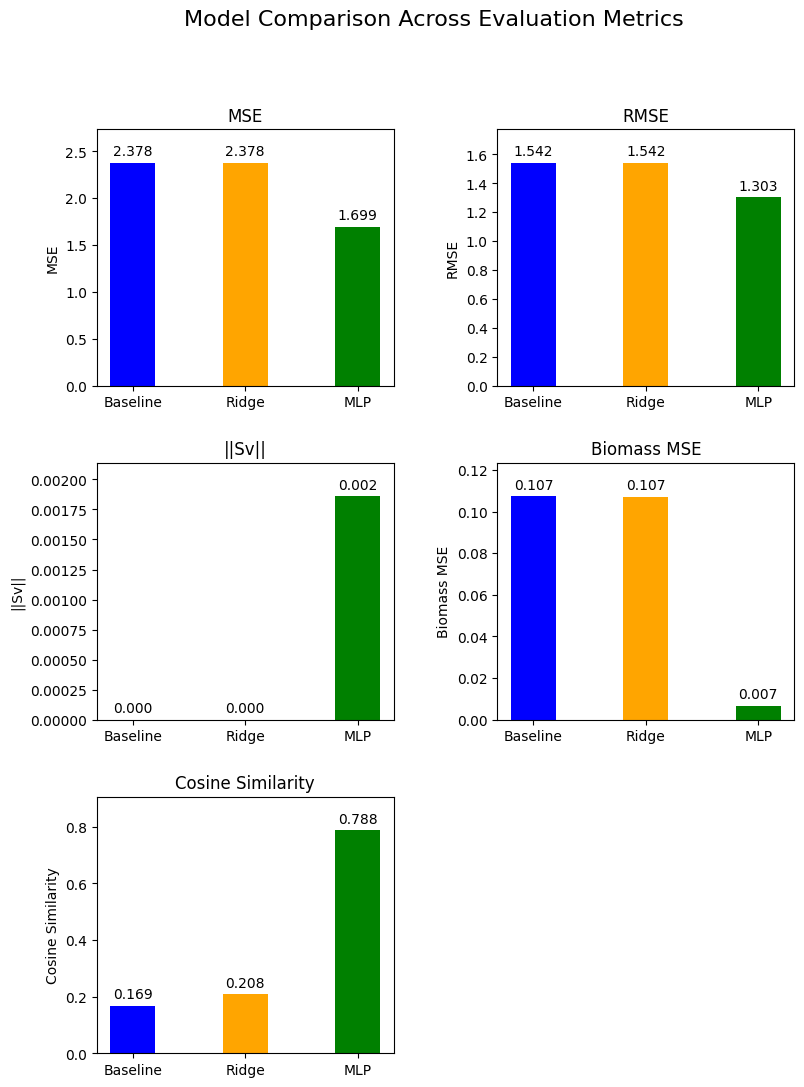

In [66]:
exp_names = ["Baseline", "Ridge", "MLP"]

metrics = {
    "MSE": [base_mse, ridge_mse, float(eval_metrics['mse'][-1])],
    "RMSE": [base_rmse, ridge_rmse, float(eval_metrics['rmse'][-1])],
    "||Sv||": [base_constraint_loss, ridge_constraint_loss, float(eval_metrics['sv_mag'][-1])],
    "Biomass MSE": [base_biomass_mse, ridge_biomass_mse, float(eval_metrics['biomass_mse'][-1])],
    "Cosine Similarity": [base_cosine_sim, ridge_cosine_sim, float(eval_metrics['cosine_sim'][-1])]
}

fig, axes = plt.subplots(3, 2, figsize=(9, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.35)
axes = axes.flatten()
colors = ["blue", "orange", "green"]  # baseline, ridge, MLP


for ax, (metric_name, values) in zip(axes, metrics.items()):
    bars = ax.bar(exp_names, values, width=0.4, color=colors)
    ymax = max(values)
    ax.set_ylim(0, ymax * 1.15)
    if metric_name == "||Sv|| (log-scaled)":
        ax.set_yscale("log")
        ax.set_ylim(min(values) * 0.8, max(values) * 5)
    ax.set_title(metric_name)
    ax.set_ylabel(metric_name)

    ax.bar_label(bars, fmt="%.3f", padding=3)

# Hide unused subplot (bottom right)
axes[-1].axis("off")

fig.suptitle("Model Comparison Across Evaluation Metrics", fontsize=16)

#plt.tight_layout()
plt.savefig('figures/fba_model_comparison_bars.png')
plt.show()

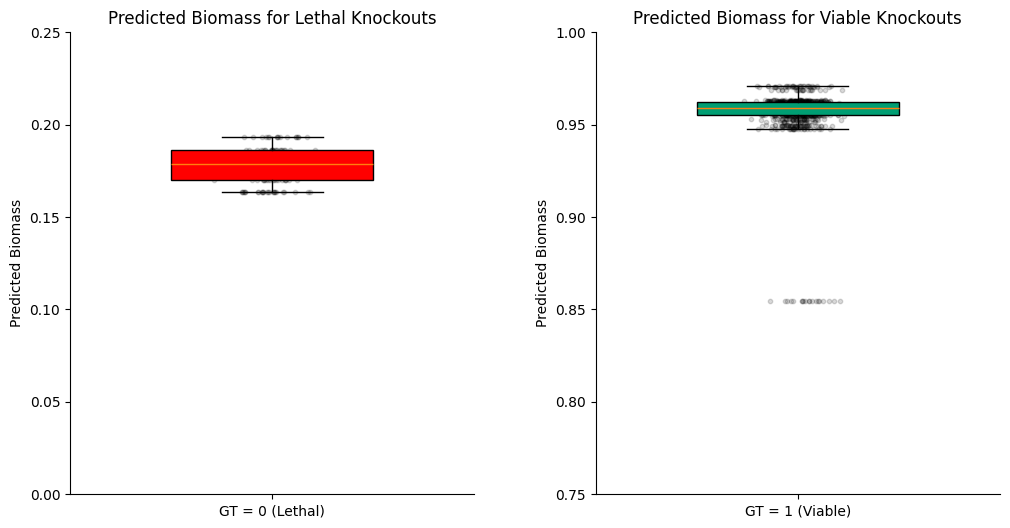

In [119]:
# Colors
colors = ["red", "green"]  # lethal, viable

# Figure for Residuals
# Create figure with side-by-side panels
fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.3)

# -----------------------------
# Panel 1: GT = 0 (Lethal)
# -----------------------------
ax0 = fig.add_subplot(gs[0,0])
box0 = ax0.boxplot([pred_lethal], patch_artist=True, widths=0.5, showfliers=False)
box0['boxes'][0].set_facecolor('red')

# Jittered points
x_jitter = np.random.normal(1, 0.04, size=len(pred_lethal))
ax0.scatter(x_jitter, pred_lethal, alpha=0.15, s=10, color='black')

ax0.set_xticks([1])
ax0.set_xticklabels(["GT = 0 (Lethal)"])
ax0.set_ylabel("Predicted Biomass")
ax0.set_title("Predicted Biomass for Lethal Knockouts")
ax0.set_ylim(0, 0.25)

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

# -----------------------------
# Panel 2: GT = 1 (Viable)
# -----------------------------
ax1 = fig.add_subplot(gs[0,1])
box1 = ax1.boxplot([pred_viable], patch_artist=True, widths=0.5, showfliers=False)
box1['boxes'][0].set_facecolor(color_viable)

# Jittered points
x_jitter = np.random.normal(1, 0.04, size=len(pred_viable))
ax1.scatter(x_jitter, pred_viable, alpha=0.15, s=10, color='black')

ax1.set_xticks([1])
ax1.set_xticklabels(["GT = 1 (Viable)"])
ax1.set_ylabel("Predicted Biomass")
ax1.set_title("Predicted Biomass for Viable Knockouts")
ax1.set_ylim(0.75, 1)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

#plt.tight_layout()
plt.savefig('figures/pred_biomass_boxes.png')
plt.show()

P (1000,) (1000,)
PP (126,) (874,)


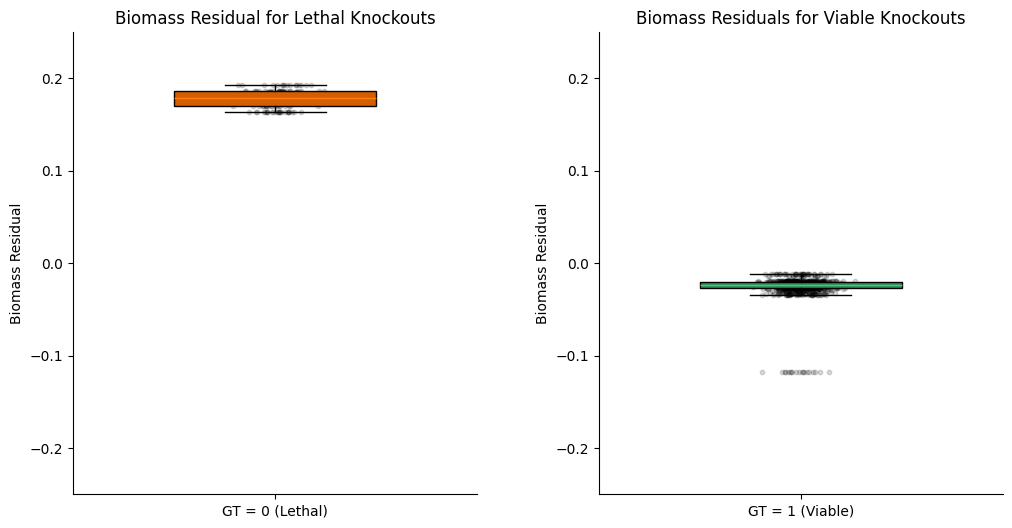

In [110]:
# Ground truth and predictions
full_v_pred = jnp.zeros((eval_biomass.shape[0], means.shape[0]), dtype=means.dtype)
full_v_pred = full_v_pred.at[:, active_rxns_mask].set(mlp_pred)
mlp_biomass_unnorm = (full_v_pred * stds) + means
pred_biomass = mlp_biomass_unnorm[:, 7]

gt_class = (eval_biomass > 0.5).astype(int)[:, 0]  # 0 = lethal, 1 = viable
print("P", pred_biomass.shape, gt_class.shape)
# Separate predictions by class
pred_lethal = pred_biomass[gt_class == 0]
pred_viable = pred_biomass[gt_class == 1]
print("PP", pred_lethal.shape, pred_viable.shape)

# Compute residuals (signed)
residuals = pred_biomass - eval_biomass[:, 0]
res_lethal = residuals[gt_class == 0]
res_viable = residuals[gt_class == 1]

# Colors
colors = ["red", "green"]  # lethal, viable

# Figure
# Create figure with side-by-side panels
fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.3)

# -----------------------------
# Panel 1: GT = 0 (Lethal)
# -----------------------------
ax0 = fig.add_subplot(gs[0,0])
box0 = ax0.boxplot([pred_lethal], patch_artist=True, widths=0.5, showfliers=False)
box0['boxes'][0].set_facecolor(color_lethal)

# Jittered points
x_jitter = np.random.normal(1, 0.04, size=len(pred_lethal))
ax0.scatter(x_jitter, res_lethal, alpha=0.15, s=10, color='black')

ax0.set_xticks([1])
ax0.set_xticklabels(["GT = 0 (Lethal)"])
ax0.set_ylabel("Biomass Residual")
ax0.set_title("Biomass Residual for Lethal Knockouts")
ax0.set_ylim(-0.25, 0.25)

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

# -----------------------------
# Panel 2: GT = 1 (Viable)
# -----------------------------
ax1 = fig.add_subplot(gs[0,1])
box1 = ax1.boxplot([res_viable], patch_artist=True, widths=0.5, showfliers=False)
box1['boxes'][0].set_facecolor(color_viable)

# Jittered points
x_jitter = np.random.normal(1, 0.04, size=len(pred_viable))
ax1.scatter(x_jitter, res_viable, alpha=0.15, s=10, color='black')

ax1.set_xticks([1])
ax1.set_xticklabels(["GT = 1 (Viable)"])
ax1.set_ylabel("Biomass Residual")
ax1.set_title("Biomass Residuals for Viable Knockouts")
ax1.set_ylim(-0.25, 0.25)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

#plt.tight_layout()
plt.savefig('figures/biomass_residual_boxes.png')
plt.show()

In [117]:
#baseline_mse = np.mean(eval_fluxes ** 2)
#model_mse = 0.27
#r_sq = 1 - (model_mse / baseline_mse)
#baseline_mse, r_sq
ridge_full_pred = jnp.zeros((eval_biomass.shape[0], means.shape[0]), dtype=means.dtype)
ridge_full_pred = ridge_full_pred.at[:, active_rxns_mask].set(ridge_pred)
ridge_biomass_unnorm = (ridge_full_pred * stds) + means
ridge_biomass = ridge_biomass_unnorm[:, 7]

ridge_lethal = ridge_biomass[gt_class == 0]
ridge_viable = ridge_biomass[gt_class == 1]
print("PP", pred_lethal.shape, pred_viable.shape)

# Compute residuals (signed)
ridge_residuals = ridge_biomass - eval_biomass[:, 0]
ridge_res_lethal = ridge_residuals[gt_class == 0]
ridge_res_viable = ridge_residuals[gt_class == 1]

# Ridge regression is predicting the same value for every sample. This is plausible since the inputs are
# one-hot vectors with only a single gene knockout (single 1). This means Ridge is trying to learn a linear mapping
# from this very sparse input to the output space and settles on the mean (the distribution is bimodal, with either
# a knockout causing death (0 biomass) or around wild-type growth (1.0), with most samples non-lethal.
ridge_viable

PP (126,) (874,)


Array([0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443, 0.8262443,
       0.8262443, 0.8262443, 0.8262443, 0.8262443, 

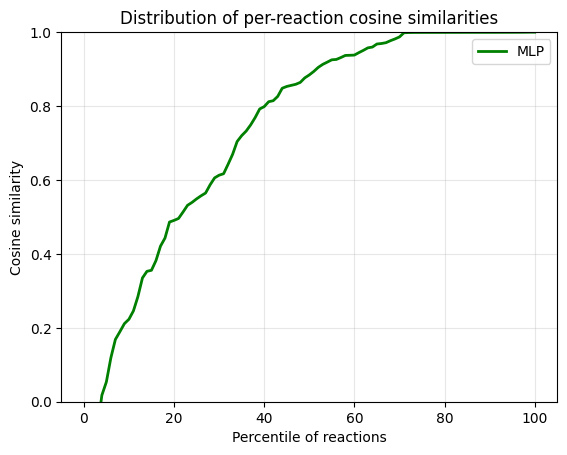

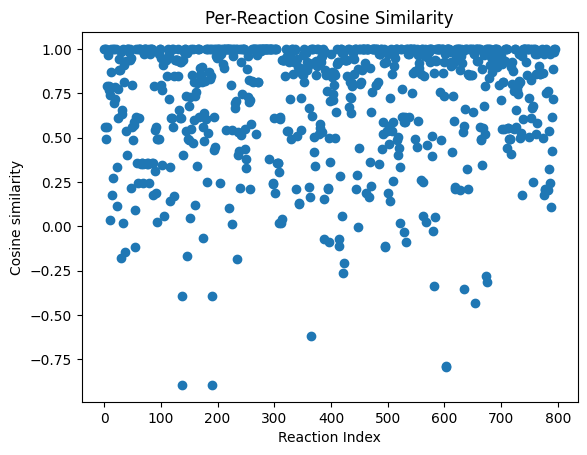

In [143]:
# Cosine similarity per reaction plot
#mlp_pred.shape
#np.dot(A,B)/|A|*|B|
#dot product is sum(A*B)

#1000, 796 --> 796

dot_per_rxn = np.sum(mlp_pred * eval_fluxes, axis=0)
cos_sim_per_rxn = dot_per_rxn / (np.linalg.norm(mlp_pred, axis=0) * np.linalg.norm(eval_fluxes, axis=0))

percentiles = np.linspace(0, 100, 101)  # 0th to 100th
mlp_percentile_vals = np.percentile(cos_sim_per_rxn, percentiles)

# Plot
plt.figure()
plt.plot(percentiles, mlp_percentile_vals, label='MLP', color='green', linewidth=2)
plt.xlabel("Percentile of reactions")
plt.ylabel("Cosine similarity")
plt.title("Distribution of per-reaction cosine similarities")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('figures/per_rxn_cos_sim_percentiles.png')


plt.figure()
plt.scatter(range(len(cos_sim_per_rxn)), cos_sim_per_rxn)
plt.xlabel("Reaction Index")
plt.ylabel("Cosine similarity")
plt.title("Per-Reaction Cosine Similarity")
plt.savefig('figures/per_rxn_cos_sim.png')

(305,)
15


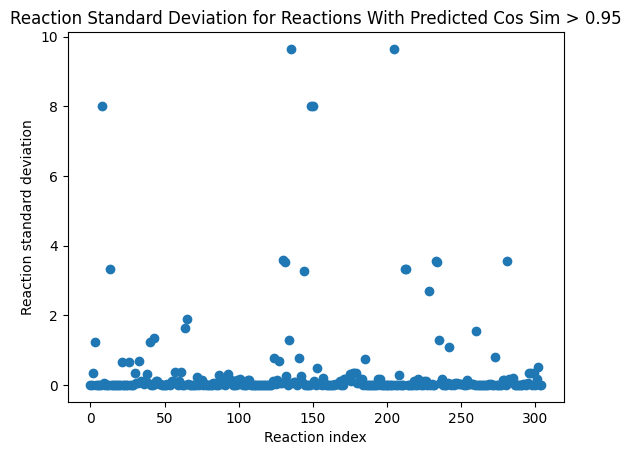

In [155]:
# Check variance of reactions with cosine similarity > 0.8
rxn_idx = cos_sim_per_rxn > 0.95
rxn_std = stds[active_rxns_mask][rxn_idx]
print(rxn_std.shape)
rxn_over_2var = rxn_std > 2.0
print(np.count_nonzero(rxn_over_2var))
plt.figure()
plt.title("Reaction Standard Deviation for Reactions With Predicted Cos Sim > 0.95")
plt.xlabel("Reaction index")
plt.ylabel("Reaction standard deviation")
plt.scatter(range(len(rxn_std)), rxn_std)
plt.savefig('figures/std_dev_for_hi_cos_sim.png')